In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re

In [11]:
!pip install emoji

In [12]:
import emoji
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
nltk.download('stopwords', quiet=True)

True

In [13]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/TER/exports/reddit_nettoye.xlsx'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
CSV_PATH  = path
TEXT_COL  = 'text'            # nom de la colonne texte
LABEL_COL = 'Perspective_label'    # nom de la colonne label (0/1 ou toxique/non-toxique)
ENCODING  = 'utf-8'           # encodage (essaie 'latin-1' si erreur)
# ─────────────────────────────────────────────

df = pd.read_excel(CSV_PATH)

print(f'Shape : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'\nColonnes : {list(df.columns)}')
df.head()

Shape : 19,258 lignes × 2 colonnes

Colonnes : ['text', 'Perspective_label']


,text,Perspective_label
0,"C'est dingue, après tout ce temps, plus de 15 ...",0
1,"Plutôt d'accord pour les SAV, c'est le but mêm...",0
2,Bordel. J'avais tapé une longue réponse. Une f...,0
3,Non pas de problème de ce côté là heureusement !,0
4,&gt;Les violences étaient clairement motivées ...,0


In [15]:

stemmer = SnowballStemmer('french')




def normaliser_repetitions(text):
    pattern_repeat = re.compile(r'([a-zA-ZÀ-ÿ])\1{2,}', re.IGNORECASE)
    return pattern_repeat.sub(r'\1', text)

# ── Pipeline principal ────────────────────────────────────────
def preprocess_tweet(text, stem=True):
    text = str(text)

    text = emoji.demojize(text, language='fr')

    text = text.lower()

    text = re.sub(r':([a-z_àâéèêëîïôùûüç]+):', r' \1 ', text)


    text = normaliser_repetitions(text)


    text = re.sub(r'http\S+|www\.\S+', ' URL ', text)


    text = re.sub(r'@\w+', ' USER ', text)


    text = re.sub(r'#(\w+)', r' \1 ', text)


    text = re.sub(r"[^\w\s']", ' ', text)


    tokens = [t for t in text.split() if len(t) >= 2]


    if stem:
        tokens = [stemmer.stem(t) for t in tokens]

    return ' '.join(tokens)



df = df.drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)
print(f'Après suppression doublons : {len(df):,} post')


df['text_clean_stemmed'] = df[TEXT_COL].apply(preprocess_tweet)
df['text_clean'] = df[TEXT_COL].apply(lambda x: preprocess_tweet(x, stem=False))


print(f'\n✅ Preprocessing terminé')
print(f'\n── Exemples ──')
for _, row in df.sample(5, random_state=42).iterrows():
    print(f'\n[Classe {row[LABEL_COL]}]')
    print(f'  AVANT : {row[TEXT_COL][:120]}')
    print(f'  APRÈS : {row["text_clean"][:120]}')

Après suppression doublons : 19,258 post

✅ Preprocessing terminé

── Exemples ──

[Classe 0]
  AVANT : C'est pas raccord à sa façon de faire. Il a gouverné grâce à des godillots, il a pas la culture du compromis politique.
  APRÈS : c'est pas raccord sa façon de faire il gouverné grâce des godillots il pas la culture du compromis politique

[Classe 0]
  AVANT : Yes.. But I'm a real hero ^(approuvé par l'Académie des Héros Mythomanes)
  APRÈS : yes but i'm real hero approuvé par l'académie des héros mythomanes

[Classe 0]
  AVANT : En reprenant les mots sages d'Umberto Eco dans *Le Pendule de Foucault* : 

*"Moi je dis qu'il existe une société secrèt
  APRÈS : en reprenant les mots sages d'umberto eco dans le pendule de foucault moi je dis qu'il existe une société secrète avec d

[Classe 0]
  AVANT : A la demande générale, la liste complète:

[Over-1-000-Companies-Have-Curtailed-Operations-in-Russia-But-Some-Remain-Yal
  APRÈS : la demande générale la liste complète over 000 companies 

In [16]:
# Nombre de mots différents dans tout le dataset (sur texte nettoyé)
tokens_uniques = set()

for txt in df["text_clean"].fillna("").astype(str):
    mots = re.findall(r"[a-zàâçéèêëîïôûùüÿñæœ']+", txt.lower())
    tokens_uniques.update(mots)

print(f"Nombre de mots différents (vocabulaire unique) : {len(tokens_uniques):,}")

Nombre de mots différents (vocabulaire unique) : 50,539


In [17]:
!pip install imbalanced-learn


In [18]:
!pip install imblearn

# NEW

══════════════════════════════════════════════════════════════════════
  VERSION : SANS STEMMING
══════════════════════════════════════════════════════════════════════
  Train : 15406 | Test : 3852
  Positifs train : 227 (1.47%)

  ▶ CV stratifiée — Naive Bayes
    AUPRC : 0.0775 ± 0.0301
    F1    : 0.1126 ± 0.0381
    F2    : 0.1781 ± 0.0593
    MCC   : 0.1168 ± 0.0496

  Seuil optimal (F2) : 0.545
  → Précision : 0.124 | Rappel : 0.333
  Seuil pour recall≥0.80 : 0.119

── Naive Bayes | Sans stemming (seuil=0.545) ──
                 precision    recall  f1-score   support

Non-toxique (0)       0.99      0.96      0.98      3795
    toxique (1)       0.12      0.33      0.18        57

       accuracy                           0.96      3852
      macro avg       0.56      0.65      0.58      3852
   weighted avg       0.98      0.96      0.97      3852


  ▶ CV stratifiée — SVM Linéaire
    AUPRC : 0.1185 ± 0.0338
    F1    : 0.0654 ± 0.0328
    F2    : 0.0432 ± 0.0217
    MCC   : 

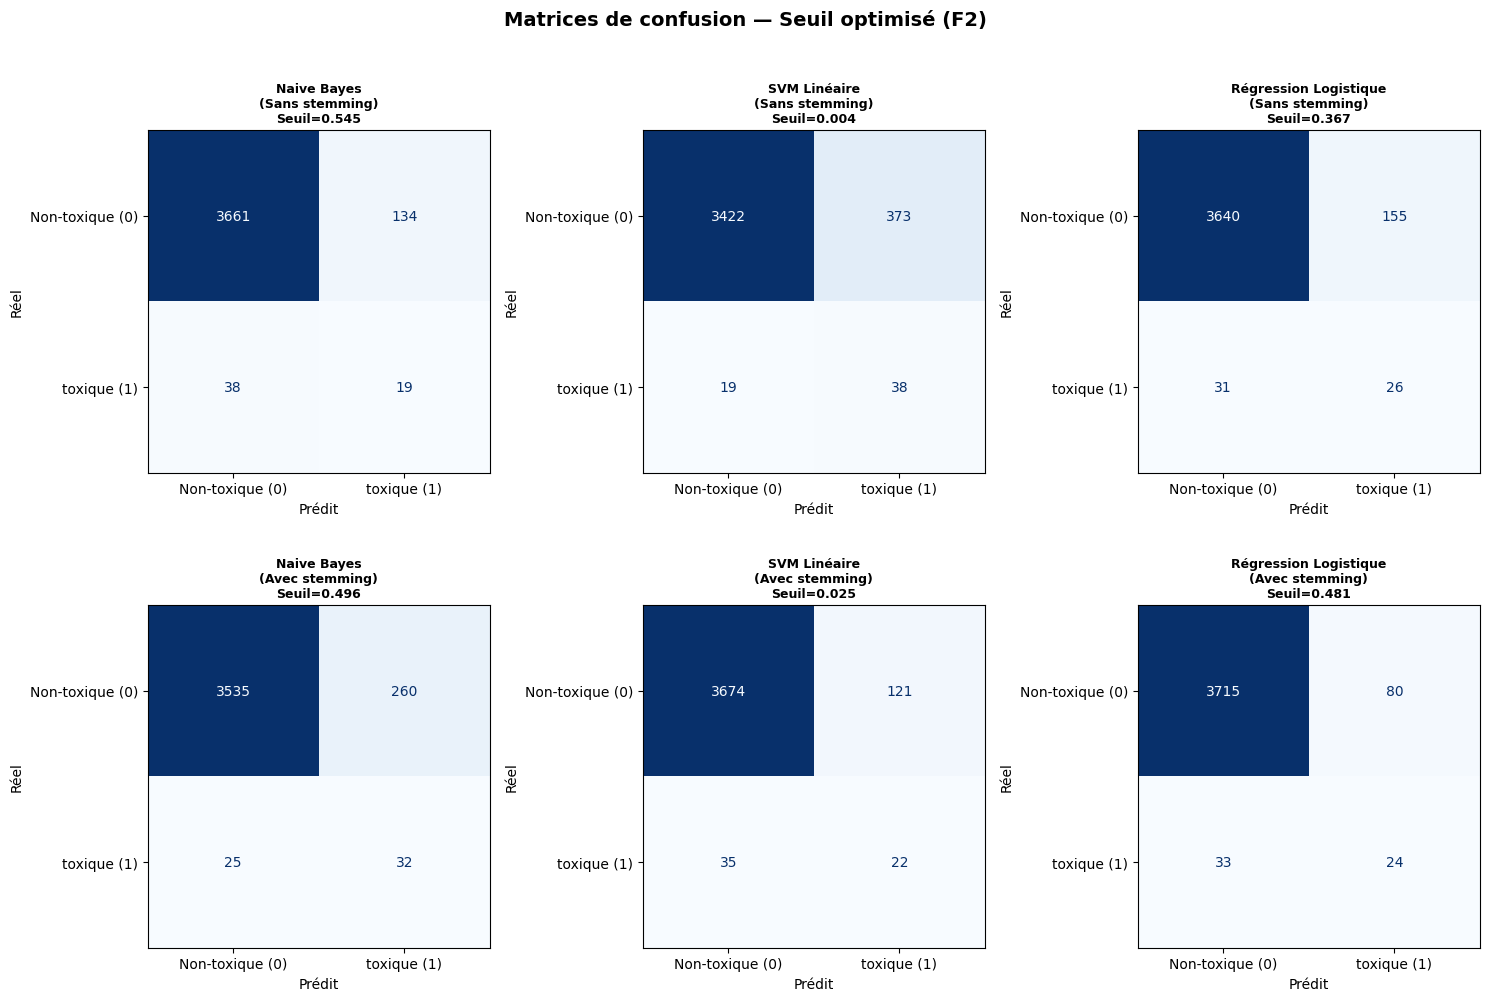

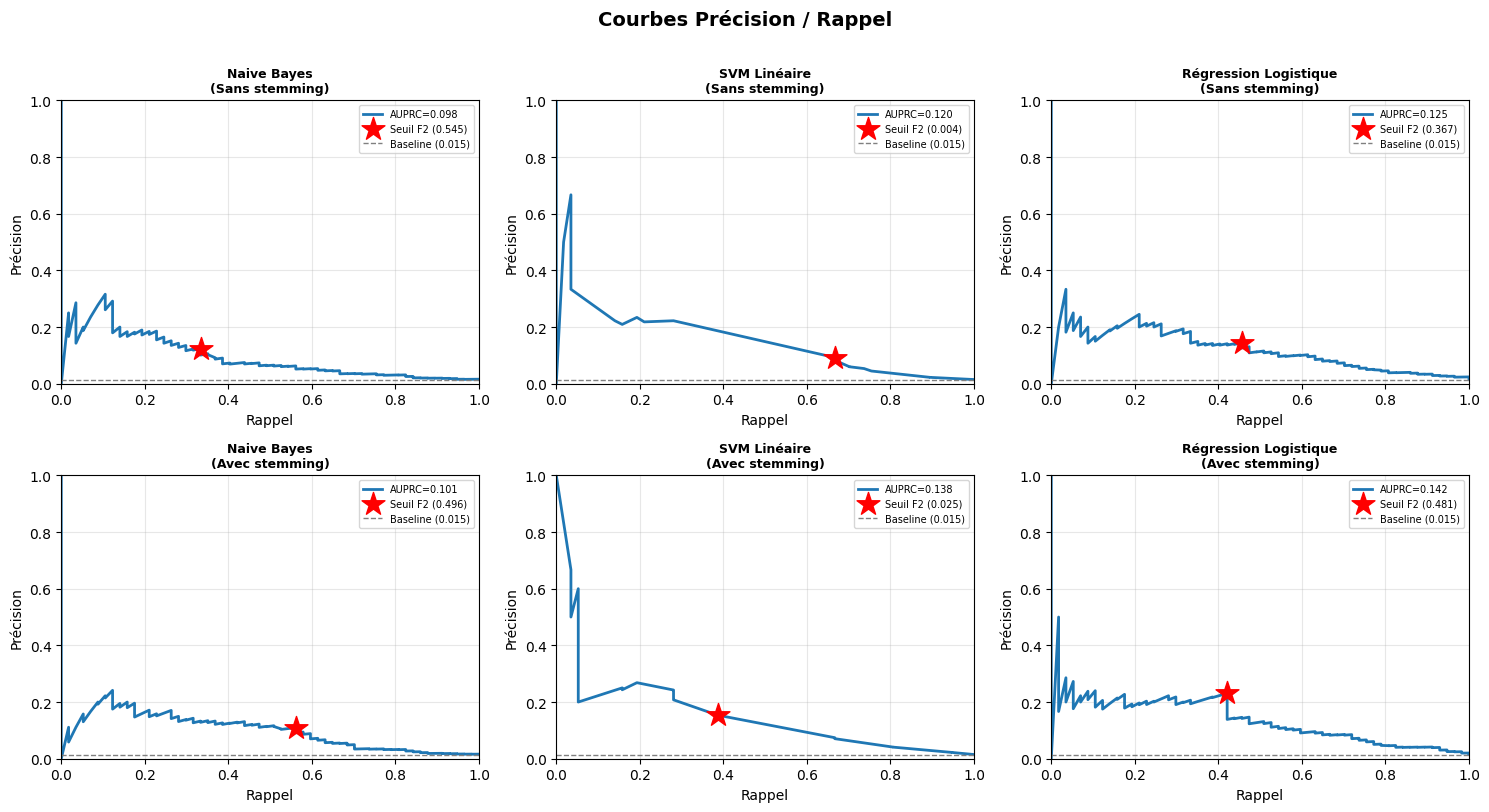

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline                        # sklearn standard (pas imblearn)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    average_precision_score, f1_score, fbeta_score,
    matthews_corrcoef, precision_recall_curve, make_scorer
)

N_SPLITS     = 5
RANDOM_STATE = 42
VERSIONS = {
    'Sans stemming': 'text_clean',
    'Avec stemming': 'text_clean_stemmed',
}
noms_classes = ['Non-toxique (0)', 'toxique (1)']


# ─────────────────────────────────────────────────────────────────────
# Suréchantillonnage TEXTE brut (avant TF-IDF)
# Duplique aléatoirement les exemples minoritaires jusqu'à ratio cible
# ─────────────────────────────────────────────────────────────────────
def oversample_text(X_text, y, ratio=0.10, random_state=42):
    """
    Duplique les positifs dans le texte brut jusqu'à atteindre
    `ratio` (ex. 0.10 = 10% de positifs dans le train).
    Plus sain que SMOTE sur TF-IDF sparse.
    """
    rng      = np.random.default_rng(random_state)
    df_tmp   = pd.DataFrame({'text': X_text, 'label': y})
    df_maj   = df_tmp[df_tmp['label'] == 0]
    df_min   = df_tmp[df_tmp['label'] == 1]

    n_maj        = len(df_maj)
    n_min_target = int(n_maj * ratio / (1 - ratio))
    n_to_add     = max(0, n_min_target - len(df_min))

    if n_to_add > 0:
        idx_extra = rng.choice(len(df_min), size=n_to_add, replace=True)
        df_extra  = df_min.iloc[idx_extra]
        df_out    = pd.concat([df_maj, df_min, df_extra]).sample(
            frac=1, random_state=random_state
        )
    else:
        df_out = df_tmp.sample(frac=1, random_state=random_state)

    return df_out['text'].values, df_out['label'].values


# ─────────────────────────────────────────────────────────────────────
# TF-IDF
# ─────────────────────────────────────────────────────────────────────
def make_tfidf():
    return TfidfVectorizer(
        ngram_range=(1, 1),
        max_features=50000,
        min_df=2,
        max_df=0.90,
        sublinear_tf=True
    )


# ─────────────────────────────────────────────────────────────────────
# MODÈLES
# ─────────────────────────────────────────────────────────────────────
def make_modeles():
    return {
        # ComplementNB : conçu pour texte déséquilibré, pas de class_weight
        # mais robuste nativement
        'Naive Bayes': ComplementNB(alpha=0.3),

        # SVM : class_weight='balanced' + calibration isotonique pour proba
        'SVM Linéaire': CalibratedClassifierCV(
            LinearSVC(
                class_weight='balanced',
                max_iter=2000,
                random_state=RANDOM_STATE
            ),
            cv=2,                   # cv=2 évite les conflits avec StratifiedKFold externe
            method='isotonic'
        ),

        # LR : class_weight='balanced', C à tuner si besoin
        'Régression Logistique': LogisticRegression(
            class_weight='balanced',
            max_iter=2000,
            random_state=RANDOM_STATE,
            solver='saga',
            C=0.5
        ),
    }


def make_pipeline(clf):
    return Pipeline([
        ('tfidf', make_tfidf()),
        ('clf',   clf)
    ])


# ─────────────────────────────────────────────────────────────────────
# MÉTRIQUES — AUPRC en priorité
# ─────────────────────────────────────────────────────────────────────
SCORING = {
    'auprc': make_scorer(average_precision_score,
                          response_method='predict_proba',
                          needs_proba=True),
    'f1':    make_scorer(f1_score,    zero_division=0),
    'f2':    make_scorer(fbeta_score, beta=2, zero_division=0),
    'mcc':   make_scorer(matthews_corrcoef),
}


# ─────────────────────────────────────────────────────────────────────
# OPTIMISATION DU SEUIL
# ─────────────────────────────────────────────────────────────────────
def optimiser_seuil(y_true, y_proba, min_recall=0.80, beta=2):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)

    fbeta_arr = ((1 + beta**2) * precisions[:-1] * recalls[:-1]) / \
                ((beta**2 * precisions[:-1]) + recalls[:-1] + 1e-9)

    best_idx  = np.argmax(fbeta_arr)
    seuil_f2  = thresholds[best_idx]

    masque       = recalls[:-1] >= min_recall
    seuil_recall = thresholds[masque][np.argmax(precisions[:-1][masque])] \
                   if masque.any() else None

    return {
        'seuil_f2':     seuil_f2,
        'precision_f2': precisions[best_idx],
        'recall_f2':    recalls[best_idx],
        'fbeta_f2':     fbeta_arr[best_idx],
        'seuil_recall': seuil_recall,
        'precisions':   precisions,
        'recalls':      recalls,
        'thresholds':   thresholds,
    }


# ─────────────────────────────────────────────────────────────────────
# VALIDATION CROISÉE MANUELLE avec suréchantillonnage texte par fold
#
# cross_validate de sklearn ne peut pas appliquer oversample_text()
# car celle-ci opère AVANT TF-IDF et en dehors du pipeline.
# On boucle donc manuellement sur les folds pour éviter toute fuite.
# ─────────────────────────────────────────────────────────────────────
def cv_avec_oversample(pipeline_fn, X_text, y, cv, ratio=0.10):
    scores = {'auprc': [], 'f1': [], 'f2': [], 'mcc': []}

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_text, y)):
        X_tr_raw, y_tr = X_text.iloc[train_idx].values, y.iloc[train_idx].values
        X_val_raw, y_val = X_text.iloc[val_idx].values, y.iloc[val_idx].values

        # Suréchantillonnage UNIQUEMENT sur le fold train
        X_tr_os, y_tr_os = oversample_text(X_tr_raw, y_tr, ratio=ratio,
                                           random_state=fold)

        pipe = pipeline_fn()
        pipe.fit(X_tr_os, y_tr_os)

        y_proba_val = pipe.predict_proba(X_val_raw)[:, 1]
        y_pred_val  = (y_proba_val >= 0.5).astype(int)

        scores['auprc'].append(average_precision_score(y_val, y_proba_val))
        scores['f1'].append(f1_score(y_val, y_pred_val, zero_division=0))
        scores['f2'].append(fbeta_score(y_val, y_pred_val, beta=2, zero_division=0))
        scores['mcc'].append(matthews_corrcoef(y_val, y_pred_val))

    return {k: np.array(v) for k, v in scores.items()}


# ─────────────────────────────────────────────────────────────────────
# BOUCLE PRINCIPALE
# ─────────────────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
y_all = df[LABEL_COL]

n_versions = len(VERSIONS)
n_modeles  = len(make_modeles())

fig_cm, axes_cm = plt.subplots(n_versions, n_modeles,
                                figsize=(5 * n_modeles, 5 * n_versions))
axes_cm = np.array(axes_cm).reshape(n_versions, n_modeles)
fig_cm.suptitle('Matrices de confusion — Seuil optimisé (F2)',
                fontsize=14, fontweight='bold', y=1.01)

fig_pr, axes_pr = plt.subplots(n_versions, n_modeles,
                                figsize=(5 * n_modeles, 4 * n_versions))
axes_pr = np.array(axes_pr).reshape(n_versions, n_modeles)
fig_pr.suptitle('Courbes Précision / Rappel',
                fontsize=14, fontweight='bold', y=1.01)

resultats_globaux = {}

for i, (version_nom, text_col) in enumerate(VERSIONS.items()):

    X_all = df[text_col]

    X_train_full, X_test, y_train, y_test = train_test_split(
        X_all, y_all,
        test_size=0.2,
        stratify=y_all,
        random_state=RANDOM_STATE
    )

    print('═' * 70)
    print(f'  VERSION : {version_nom.upper()}')
    print('═' * 70)
    print(f'  Train : {len(y_train)} | Test : {len(y_test)}')
    print(f'  Positifs train : {y_train.sum()} ({y_train.mean()*100:.2f}%)')

    modeles = make_modeles()

    for j, (nom_clf, clf) in enumerate(modeles.items()):

        # Closure pour recréer un pipeline frais à chaque fold
        def pipeline_fn(clf=clf):
            return make_pipeline(clf)

        # ── CV manuelle avec oversampling texte par fold ─────────────
        print(f'\n  ▶ CV stratifiée — {nom_clf}')
        cv_scores = cv_avec_oversample(pipeline_fn, X_train_full, y_train,
                                       cv=cv, ratio=0.10)

        for metric, vals in cv_scores.items():
            print(f'    {metric.upper():5s} : {vals.mean():.4f} ± {vals.std():.4f}')

        # ── Entraînement final avec oversampling sur tout le train ────
        X_tr_os, y_tr_os = oversample_text(
            X_train_full.values, y_train.values,
            ratio=0.10, random_state=RANDOM_STATE
        )
        pipeline_final = make_pipeline(clf)
        pipeline_final.fit(X_tr_os, y_tr_os)

        # ── Probabilités + seuil ─────────────────────────────────────
        y_proba   = pipeline_final.predict_proba(X_test.values)[:, 1]
        res_seuil = optimiser_seuil(y_test, y_proba, min_recall=0.80)
        seuil_opt = res_seuil['seuil_f2']

        print(f'\n  Seuil optimal (F2) : {seuil_opt:.3f}')
        print(f'  → Précision : {res_seuil["precision_f2"]:.3f} | '
              f'Rappel : {res_seuil["recall_f2"]:.3f}')
        if res_seuil['seuil_recall'] is not None:
            print(f'  Seuil pour recall≥0.80 : {res_seuil["seuil_recall"]:.3f}')

        y_pred = (y_proba >= seuil_opt).astype(int)

        print(f'\n── {nom_clf} | {version_nom} (seuil={seuil_opt:.3f}) ──')
        print(classification_report(y_test, y_pred, target_names=noms_classes))

        auprc_test = average_precision_score(y_test, y_proba)
        resultats_globaux[f'{version_nom}_{nom_clf}'] = {
            'AUPRC (test)':    auprc_test,
            'AUPRC (CV moy.)': cv_scores['auprc'].mean(),
            'MCC':             matthews_corrcoef(y_test, y_pred),
            'F2':              fbeta_score(y_test, y_pred, beta=2, zero_division=0),
            'Seuil optimal':   seuil_opt,
        }

        # ── Matrice de confusion ──────────────────────────────────────
        ax_cm = axes_cm[i][j]
        ConfusionMatrixDisplay(
            confusion_matrix(y_test, y_pred),
            display_labels=noms_classes
        ).plot(ax=ax_cm, colorbar=False, cmap='Blues')
        ax_cm.set_title(f'{nom_clf}\n({version_nom})\nSeuil={seuil_opt:.3f}',
                        fontsize=9, fontweight='bold')
        ax_cm.set_xlabel('Prédit')
        ax_cm.set_ylabel('Réel')

        # ── Courbe PR ─────────────────────────────────────────────────
        ax_pr = axes_pr[i][j]
        ax_pr.plot(res_seuil['recalls'], res_seuil['precisions'],
                   lw=2, label=f'AUPRC={auprc_test:.3f}')
        ax_pr.scatter(
            res_seuil['recall_f2'], res_seuil['precision_f2'],
            marker='*', s=300, color='red', zorder=5,
            label=f'Seuil F2 ({seuil_opt:.3f})'
        )
        ax_pr.axhline(y=y_test.mean(), color='gray', linestyle='--',
                      linewidth=1, label=f'Baseline ({y_test.mean():.3f})')
        ax_pr.set_xlabel('Rappel')
        ax_pr.set_ylabel('Précision')
        ax_pr.set_title(f'{nom_clf}\n({version_nom})', fontsize=9, fontweight='bold')
        ax_pr.legend(fontsize=7)
        ax_pr.set_xlim([0, 1])
        ax_pr.set_ylim([0, 1])
        ax_pr.grid(alpha=0.3)

# ─────────────────────────────────────────────────────────────────────
# RÉCAPITULATIF
# ─────────────────────────────────────────────────────────────────────
print('\n' + '═' * 70)
print('  RÉCAPITULATIF GLOBAL')
print('═' * 70)
df_recap = pd.DataFrame(resultats_globaux).T.round(4)
print(df_recap.to_string())

fig_cm.tight_layout()
fig_pr.tight_layout()
plt.show()

# VERSION AVEC VOTE MAJORITAIRE

══════════════════════════════════════════════════════════════════════
  VERSION : SANS STEMMING
══════════════════════════════════════════════════════════════════════
  Positifs  : 227 | Négatifs : 15179 | Modèles : 66
══════════════════════════════════════════════════════════════════════
  [Naive Bayes] Modèle   1/66 entraîné...
  [Naive Bayes] Modèle  10/66 entraîné...
  [Naive Bayes] Modèle  20/66 entraîné...
  [Naive Bayes] Modèle  30/66 entraîné...
  [Naive Bayes] Modèle  40/66 entraîné...
  [Naive Bayes] Modèle  50/66 entraîné...
  [Naive Bayes] Modèle  60/66 entraîné...

── Naive Bayes | Sans stemming ──
                 precision    recall  f1-score   support

Non-toxique (0)       0.99      0.85      0.91      3795
    toxique (1)       0.06      0.67      0.11        57

       accuracy                           0.84      3852
      macro avg       0.53      0.76      0.51      3852
   weighted avg       0.98      0.84      0.90      3852

  [SVM Linéaire] Modèle   1/66 entr

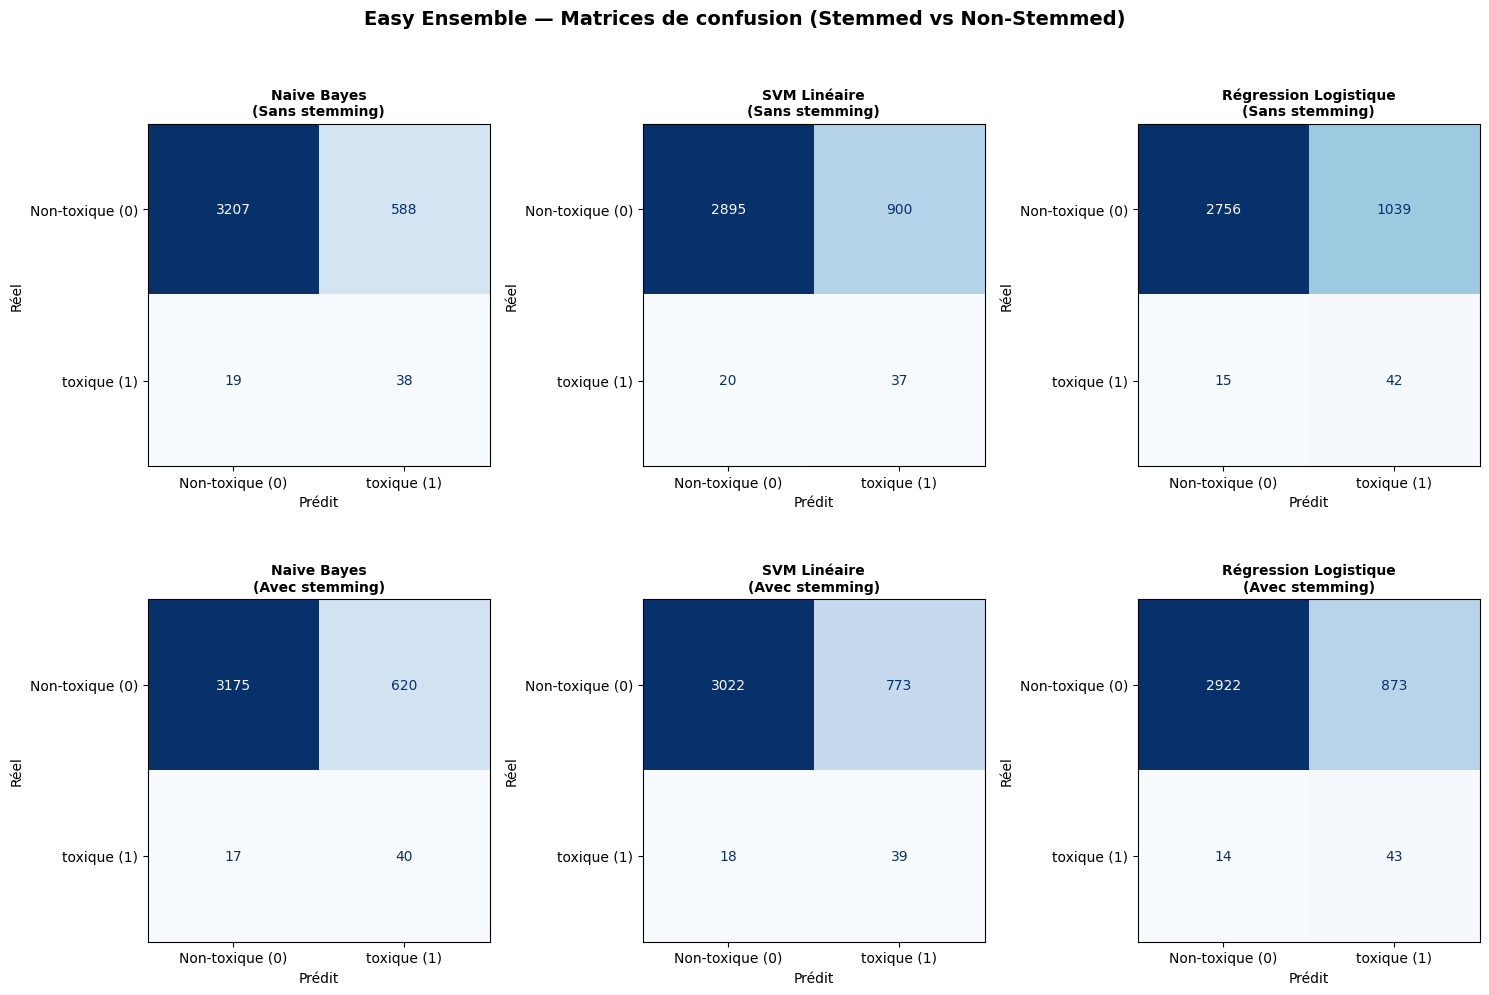

In [20]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import resample
from imblearn.pipeline import Pipeline
from scipy.stats import mode
import matplotlib.pyplot as plt


MODELES = {
    'Naive Bayes'          : ComplementNB(),
    'SVM Linéaire'         : LinearSVC(max_iter=2000, random_state=42),
    'Régression Logistique': LogisticRegression(max_iter=2000, random_state=42),
}

VERSIONS = {
    'Sans stemming' : 'text_clean',
    'Avec stemming' : 'text_clean_stemmed',
}

noms_classes = ['Non-toxique (0)', 'toxique (1)']



y_all = df[LABEL_COL]

n_versions = len(VERSIONS)
n_modeles  = len(MODELES)

fig, axes = plt.subplots(
    n_versions, n_modeles,
    figsize=(5 * n_modeles, 5 * n_versions)
)
axes = np.array(axes).reshape(n_versions, n_modeles)
fig.suptitle('Easy Ensemble — Matrices de confusion (Stemmed vs Non-Stemmed)',
             fontsize=14, fontweight='bold', y=1.01)


for i, (version_nom, text_col) in enumerate(VERSIONS.items()):

    X_all = df[text_col]


    X_train_full, X_test_global, y_train_full, y_test_global = train_test_split(
        X_all, y_all,
        test_size=0.2,
        stratify=y_all,
        random_state=42
    )


    train_df = pd.DataFrame({'text': X_train_full, 'label': y_train_full})
    df_maj   = train_df[train_df['label'] == 0]
    df_min   = train_df[train_df['label'] == 1]

    n_min    = len(df_min)
    n_maj    = len(df_maj)
    n_models = n_maj // n_min

    print('═'*70)
    print(f'  VERSION : {version_nom.upper()}')
    print('═'*70)
    print(f'  Positifs  : {n_min} | Négatifs : {n_maj} | Modèles : {n_models}')
    print('═'*70)

    for j, (nom_clf, clf) in enumerate(MODELES.items()):

        def make_pipeline_ensemble(clf):
            return Pipeline([
                ('tfidf', TfidfVectorizer(
                    ngram_range=(1, 1),
                    max_features=50539,
                    min_df=2,
                    max_df=0.90,
                    sublinear_tf=True
                )),
                ('clf', clf)
            ])

        all_predictions = []

        for k in range(n_models):

            df_maj_sample = resample(
                df_maj,
                n_samples=n_min,
                replace=False,
                random_state=k
            )

            X_sample = pd.concat([df_maj_sample['text'], df_min['text']])
            y_sample = pd.concat([df_maj_sample['label'], df_min['label']])

            pipeline = make_pipeline_ensemble(clf)
            pipeline.fit(X_sample, y_sample)
            all_predictions.append(pipeline.predict(X_test_global))

            if (k + 1) % 10 == 0 or k == 0:
                print(f'  [{nom_clf}] Modèle {k+1:>3}/{n_models} entraîné...')


        predictions_matrix   = np.array(all_predictions)
        final_predictions, _ = mode(predictions_matrix, axis=0)
        final_predictions    = final_predictions.flatten()


        print(f'\n── {nom_clf} | {version_nom} ──')
        print(classification_report(y_test_global, final_predictions, target_names=noms_classes))


        cm   = confusion_matrix(y_test_global, final_predictions)
        ax   = axes[i][j]
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=noms_classes)
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(f'{nom_clf}\n({version_nom})', fontsize=10, fontweight='bold')
        ax.set_xlabel('Prédit')
        ax.set_ylabel('Réel')

plt.tight_layout()
plt.show()

# version balanced

══════════════════════════════════════════════════════════════════════════════════════════
                      ANALYSE DES PERFORMANCES (Déséquilibre: 1.4%)                       
══════════════════════════════════════════════════════════════════════════════════════════

▶ VERSION : SANS STEMMING
Modèle                       Précision       Recall     F1-Score        AUPRC
───────────────────────── ──────────── ──────────── ──────────── ────────────
Naive Bayes (Comp)               0.050        0.324        0.087        0.047
SVM Linéaire                     0.047        0.246        0.079        0.075
Régression Logistique            0.054        0.377        0.094        0.096

▶ VERSION : AVEC STEMMING
Modèle                       Précision       Recall     F1-Score        AUPRC
───────────────────────── ──────────── ──────────── ──────────── ────────────
Naive Bayes (Comp)               0.065        0.422        0.113        0.063
SVM Linéaire                     0.064        0.2

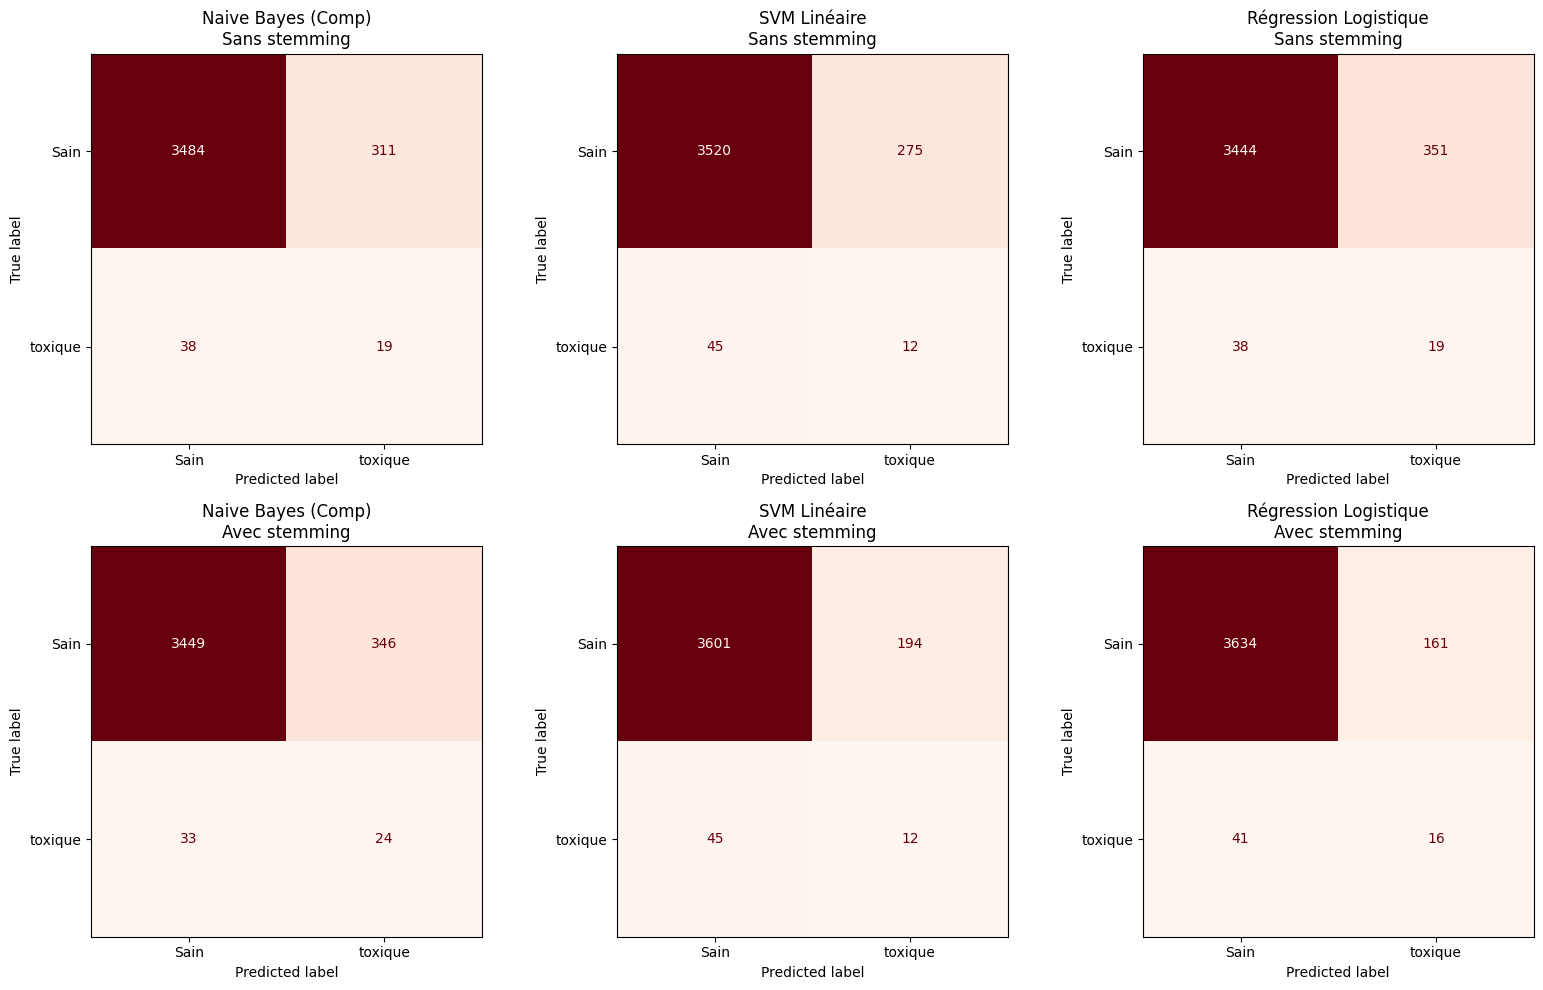

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             make_scorer, average_precision_score, precision_score, recall_score)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np


VERSIONS = {
    'Sans stemming' : df['text_clean'],
    'Avec stemming' : df['text_clean_stemmed'],
}

MODELES = {
    'Naive Bayes (Comp)'   : ComplementNB(),
    'SVM Linéaire'         : LinearSVC(max_iter=5000, random_state=42, class_weight='balanced', dual=False),
    'Régression Logistique': LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced'),
}


METRIQUES = {
    'precision': make_scorer(precision_score, pos_label=1),
    'recall':    make_scorer(recall_score, pos_label=1),
    'f1_pos':    'f1',
    'auprc':     'average_precision'
}

y = df[LABEL_COL]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_pipeline(clf):
    return Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True,
                                 max_features=5000, min_df=3)),
        ('smote', SMOTE(sampling_strategy=0.1, random_state=42)),
        ('clf', clf)
    ])

# --- CROSS-VALIDATION ---
print('═'*90)
print(f'{"ANALYSE DES PERFORMANCES (Déséquilibre: 1.4%)":^90}')
print('═'*90)

for version_nom, X in VERSIONS.items():
    print(f'\n▶ VERSION : {version_nom.upper()}')
    print(f'{"Modèle":<25} {"Précision":>12} {"Recall":>12} {"F1-Score":>12} {"AUPRC":>12}')
    print(f'{"─"*25} {"─"*12} {"─"*12} {"─"*12} {"─"*12}')

    for nom_clf, clf in MODELES.items():
        pipeline = make_pipeline(clf)
        scores = cross_validate(pipeline, X, y, cv=cv, scoring=METRIQUES)

        pre  = scores['test_precision'].mean()
        rec  = scores['test_recall'].mean()
        f1   = scores['test_f1_pos'].mean()
        auc  = scores['test_auprc'].mean()

        print(f'{nom_clf:<25} {pre:>12.3f} {rec:>12.3f} {f1:>12.3f} {auc:>12.3f}')


fig, axes = plt.subplots(len(VERSIONS), len(MODELES), figsize=(16, 10))
axes = np.array(axes).reshape(len(VERSIONS), len(MODELES))

for i, (version_nom, X) in enumerate(VERSIONS.items()):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    for j, (nom_clf, clf) in enumerate(MODELES.items()):
        pipe = make_pipeline(clf)
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)


        print(f"\nReport pour {nom_clf} ({version_nom}):")
        print(classification_report(y_test, y_pred, target_names=['Sain', 'toxique']))

        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sain', 'toxique'])
        disp.plot(ax=axes[i][j], cmap='Reds', colorbar=False)
        axes[i][j].set_title(f"{nom_clf}\n{version_nom}")

plt.tight_layout()
plt.show()

# VERSION NORMAL

══════════════════════════════════════════════════════════════════════
  CROSS-VALIDATION 5 FOLDS
══════════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────────
  VERSION : SANS STEMMING
──────────────────────────────────────────────────────────────────────
  Modèle                      F1-macro  F1-weighted    ROC-AUC  Précision     Recall
  ───────────────────────── ────────── ──────────── ────────── ────────── ──────────
  Naive Bayes                    0.545        0.950      0.738      0.533      0.645  (±0.014)
  SVM Linéaire                   0.550        0.967      0.718      0.559      0.578  (±0.011)
  Régression Logistique          0.581        0.972      0.784      0.584      0.595  (±0.034)

──────────────────────────────────────────────────────────────────────
  VERSION : AVEC STEMMING
──────────────────────────────────────────────────────────────────────
  Modèle                      F1-macro

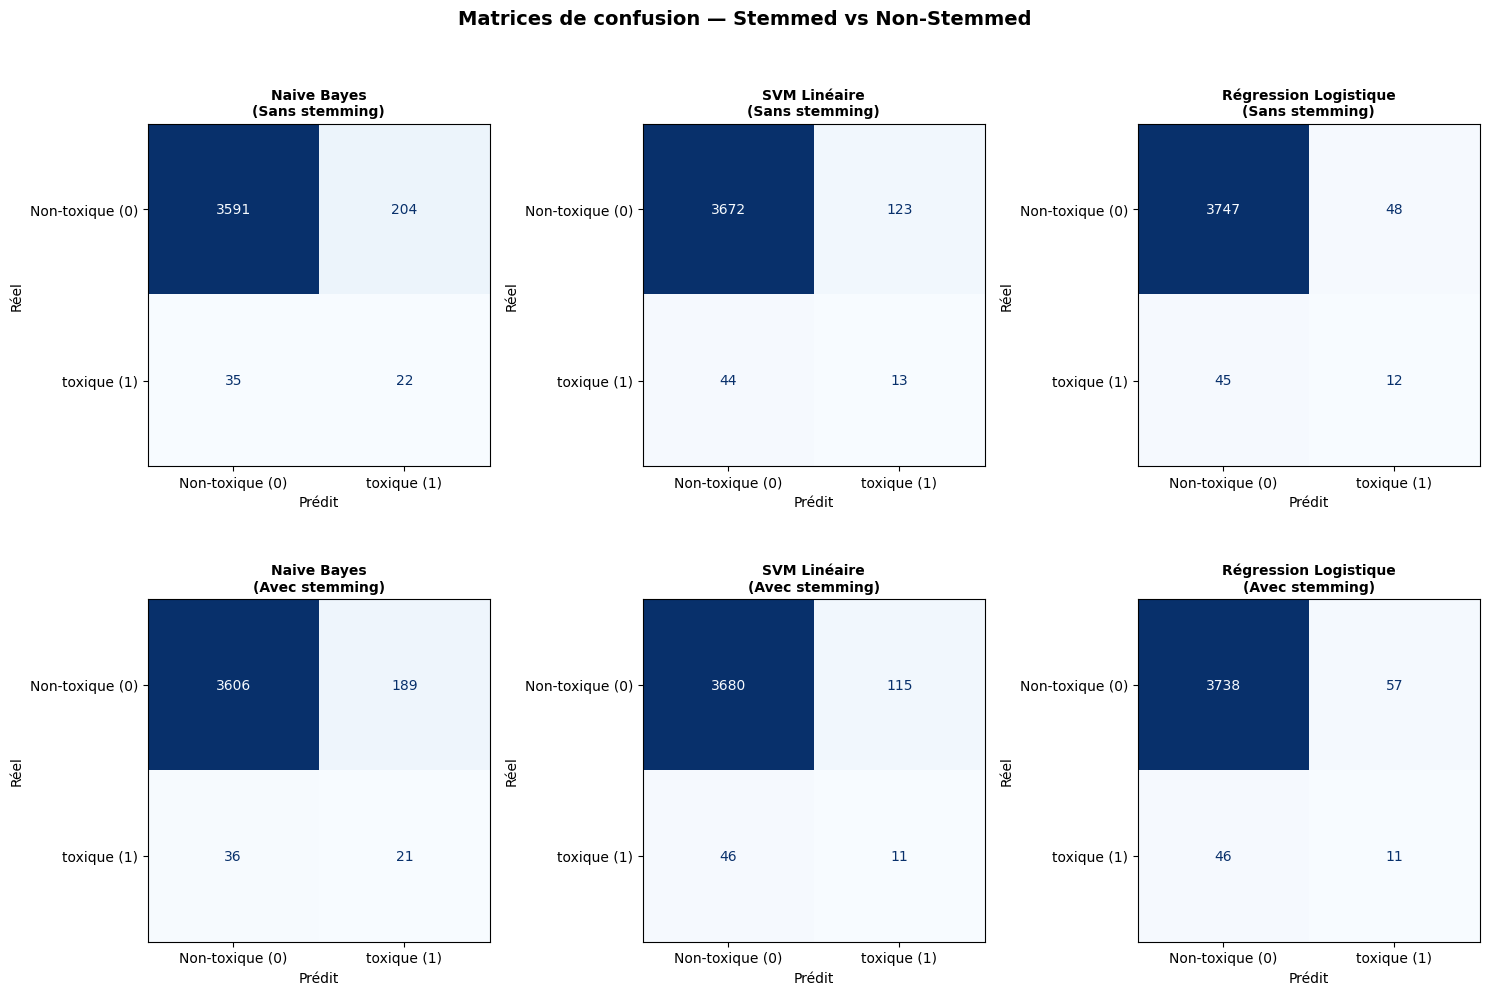

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np

VERSIONS = {
    'Sans stemming' : df['text_clean'],
    'Avec stemming' : df['text_clean_stemmed'],
}

MODELES = {
    'Naive Bayes'          : ComplementNB(),
    'SVM Linéaire'         : LinearSVC(max_iter=2000, random_state=42, class_weight='balanced'),
    'Régression Logistique': LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced'),
}

METRIQUES = ['f1_macro', 'f1_weighted', 'roc_auc', 'precision_macro', 'recall_macro']

y = df[LABEL_COL]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_pipeline(clf):
    return Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True,
                                   max_features=50000, min_df=2)),
        ('smote', SMOTE(random_state=42)),
        ('clf',   clf)
    ])


print('═'*70)
print('  CROSS-VALIDATION 5 FOLDS')
print('═'*70)

tous_resultats = {}

for version_nom, X in VERSIONS.items():
    print(f'\n{"─"*70}')
    print(f'  VERSION : {version_nom.upper()}')
    print(f'{"─"*70}')
    print(f'  {"Modèle":<25} {"F1-macro":>10} {"F1-weighted":>12} {"ROC-AUC":>10} {"Précision":>10} {"Recall":>10}')
    print(f'  {"─"*25} {"─"*10} {"─"*12} {"─"*10} {"─"*10} {"─"*10}')

    for nom_clf, clf in MODELES.items():
        pipeline = make_pipeline(clf)
        scores = cross_validate(pipeline, X, y, cv=cv, scoring=METRIQUES)
        tous_resultats[(version_nom, nom_clf)] = scores

        f1m  = scores['test_f1_macro'].mean()
        f1w  = scores['test_f1_weighted'].mean()
        auc  = scores['test_roc_auc'].mean()
        pre  = scores['test_precision_macro'].mean()
        rec  = scores['test_recall_macro'].mean()
        std  = scores['test_f1_macro'].std()

        print(f'  {nom_clf:<25} {f1m:>10.3f} {f1w:>12.3f} {auc:>10.3f} {pre:>10.3f} {rec:>10.3f}  (±{std:.3f})')


print(f'\n\n{"═"*70}')
print('  MATRICES DE CONFUSION — Ensemble test final (80/20)')
print('═'*70)

noms_classes = ['Non-toxique (0)', 'toxique (1)']
n_versions   = len(VERSIONS)
n_modeles    = len(MODELES)

fig, axes = plt.subplots(
    n_versions, n_modeles,
    figsize=(5 * n_modeles, 5 * n_versions)
)
axes = np.array(axes).reshape(n_versions, n_modeles)
fig.suptitle('Matrices de confusion — Stemmed vs Non-Stemmed', fontsize=14, fontweight='bold', y=1.01)

for i, (version_nom, X) in enumerate(VERSIONS.items()):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    for j, (nom_clf, clf) in enumerate(MODELES.items()):
        pipeline = make_pipeline(clf)
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        ax = axes[i][j]

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=noms_classes)
        disp.plot(ax=ax, colorbar=False, cmap='Blues')

        ax.set_title(f'{nom_clf}\n({version_nom})', fontsize=10, fontweight='bold')
        ax.set_xlabel('Prédit')
        ax.set_ylabel('Réel')

        print(f'\n── {nom_clf} | {version_nom} ──')
        print(classification_report(y_test, y_pred, target_names=noms_classes))

plt.tight_layout()
plt.show()

══════════════════════════════════════════════════════════════════════
  DIAGNOSTIC OVERFITTING / UNDERFITTING
══════════════════════════════════════════════════════════════════════

── Naive Bayes | Sans stemming ──
  F1 Train : 0.701
  F1 Test  : 0.562
  Gap      : 0.139

── SVM Linéaire | Sans stemming ──
  F1 Train : 0.875
  F1 Test  : 0.556
  Gap      : 0.319

── Régression Logistique | Sans stemming ──
  F1 Train : 0.896
  F1 Test  : 0.596
  Gap      : 0.300

── Naive Bayes | Avec stemming ──
  F1 Train : 0.714
  F1 Test  : 0.564
  Gap      : 0.150

── SVM Linéaire | Avec stemming ──
  F1 Train : 0.893
  F1 Test  : 0.549
  Gap      : 0.343

── Régression Logistique | Avec stemming ──
  F1 Train : 0.898
  F1 Test  : 0.581
  Gap      : 0.317


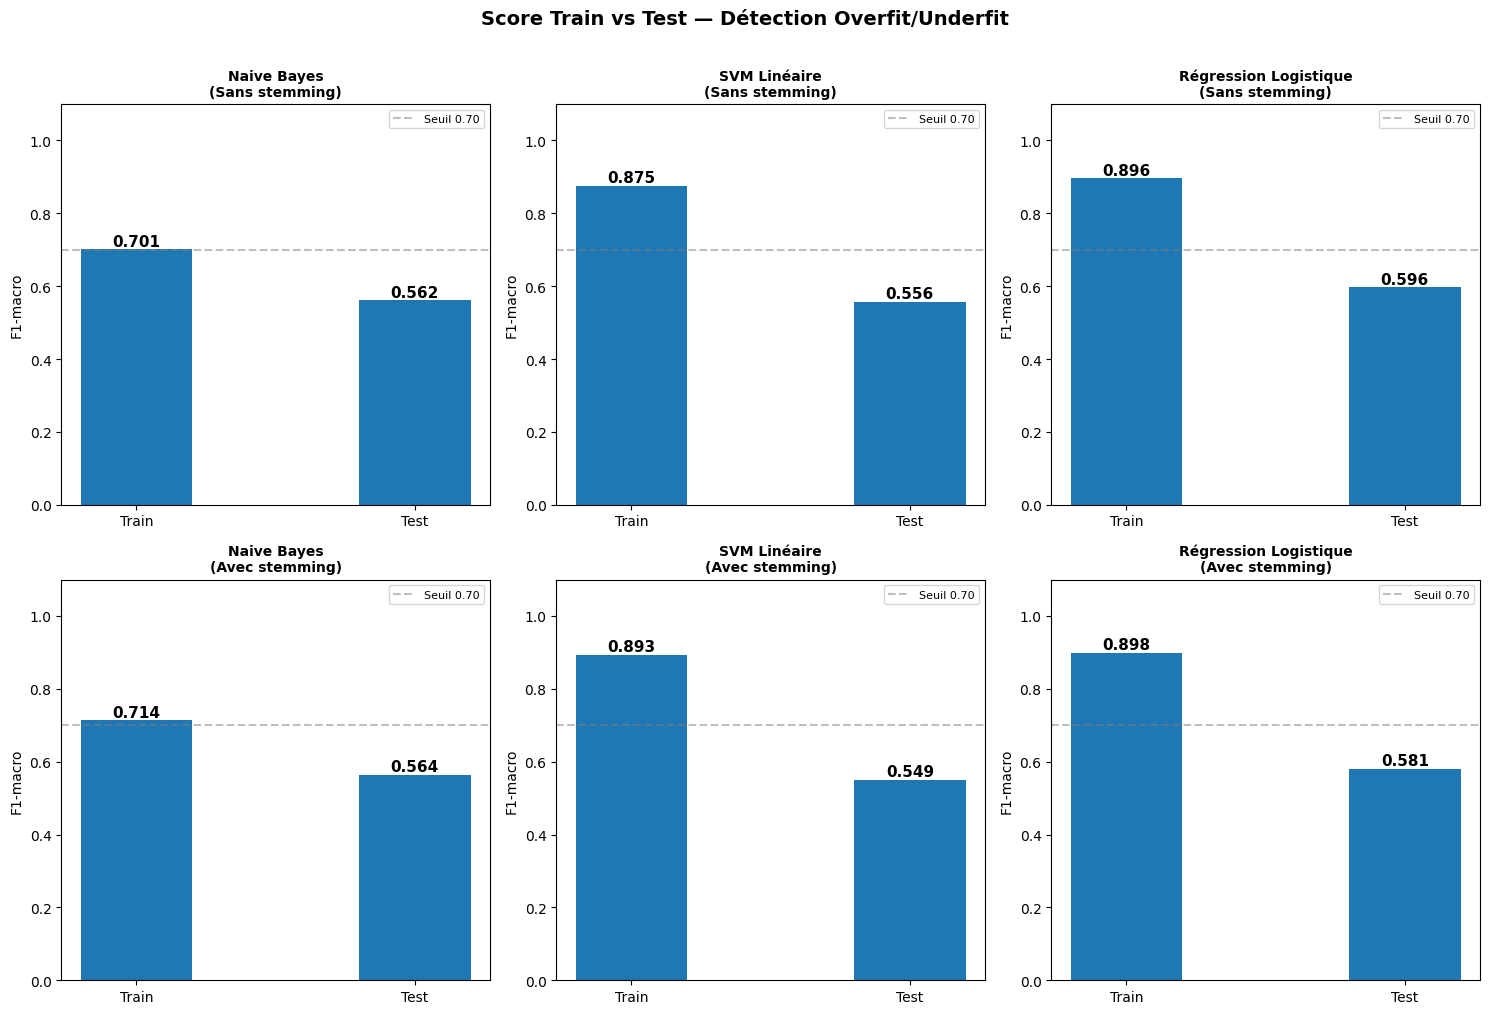

In [25]:
# ══════════════════════════════════════════════════════════════
#  DIAGNOSTIC OVERFITTING / UNDERFITTING
# ══════════════════════════════════════════════════════════════

from sklearn.metrics import f1_score

print('═'*70)
print('  DIAGNOSTIC OVERFITTING / UNDERFITTING')
print('═'*70)

fig, axes = plt.subplots(n_versions, n_modeles, figsize=(5 * n_modeles, 5 * n_versions))
fig.suptitle('Score Train vs Test — Détection Overfit/Underfit', fontsize=14, fontweight='bold', y=1.01)

for i, (version_nom, X) in enumerate(VERSIONS.items()):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    for j, (nom_clf, clf) in enumerate(MODELES.items()):
        pipeline = make_pipeline(clf)
        pipeline.fit(X_train, y_train)

        # Score directement sur train et test
        score_train = f1_score(y_train, pipeline.predict(X_train), average='macro')
        score_test  = f1_score(y_test,  pipeline.predict(X_test),  average='macro')
        gap         = score_train - score_test



        # ── Affichage texte ───────────────────────────────────
        print(f'\n── {nom_clf} | {version_nom} ──')
        print(f'  F1 Train : {score_train:.3f}')
        print(f'  F1 Test  : {score_test:.3f}')
        print(f'  Gap      : {gap:.3f}')


        # ── Graphique barres ──────────────────────────────────
        ax = axes[i][j]
        bars = ax.bar(['Train', 'Test'], [score_train, score_test],width=0.4)

        for bar, val in zip(bars, [score_train, score_test]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

        ax.set_ylim(0, 1.1)
        ax.set_title(f'{nom_clf}\n({version_nom})', fontsize=10, fontweight='bold')
        ax.set_ylabel('F1-macro')
        ax.axhline(y=0.70, color='gray', linestyle='--', alpha=0.5, label='Seuil 0.70')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

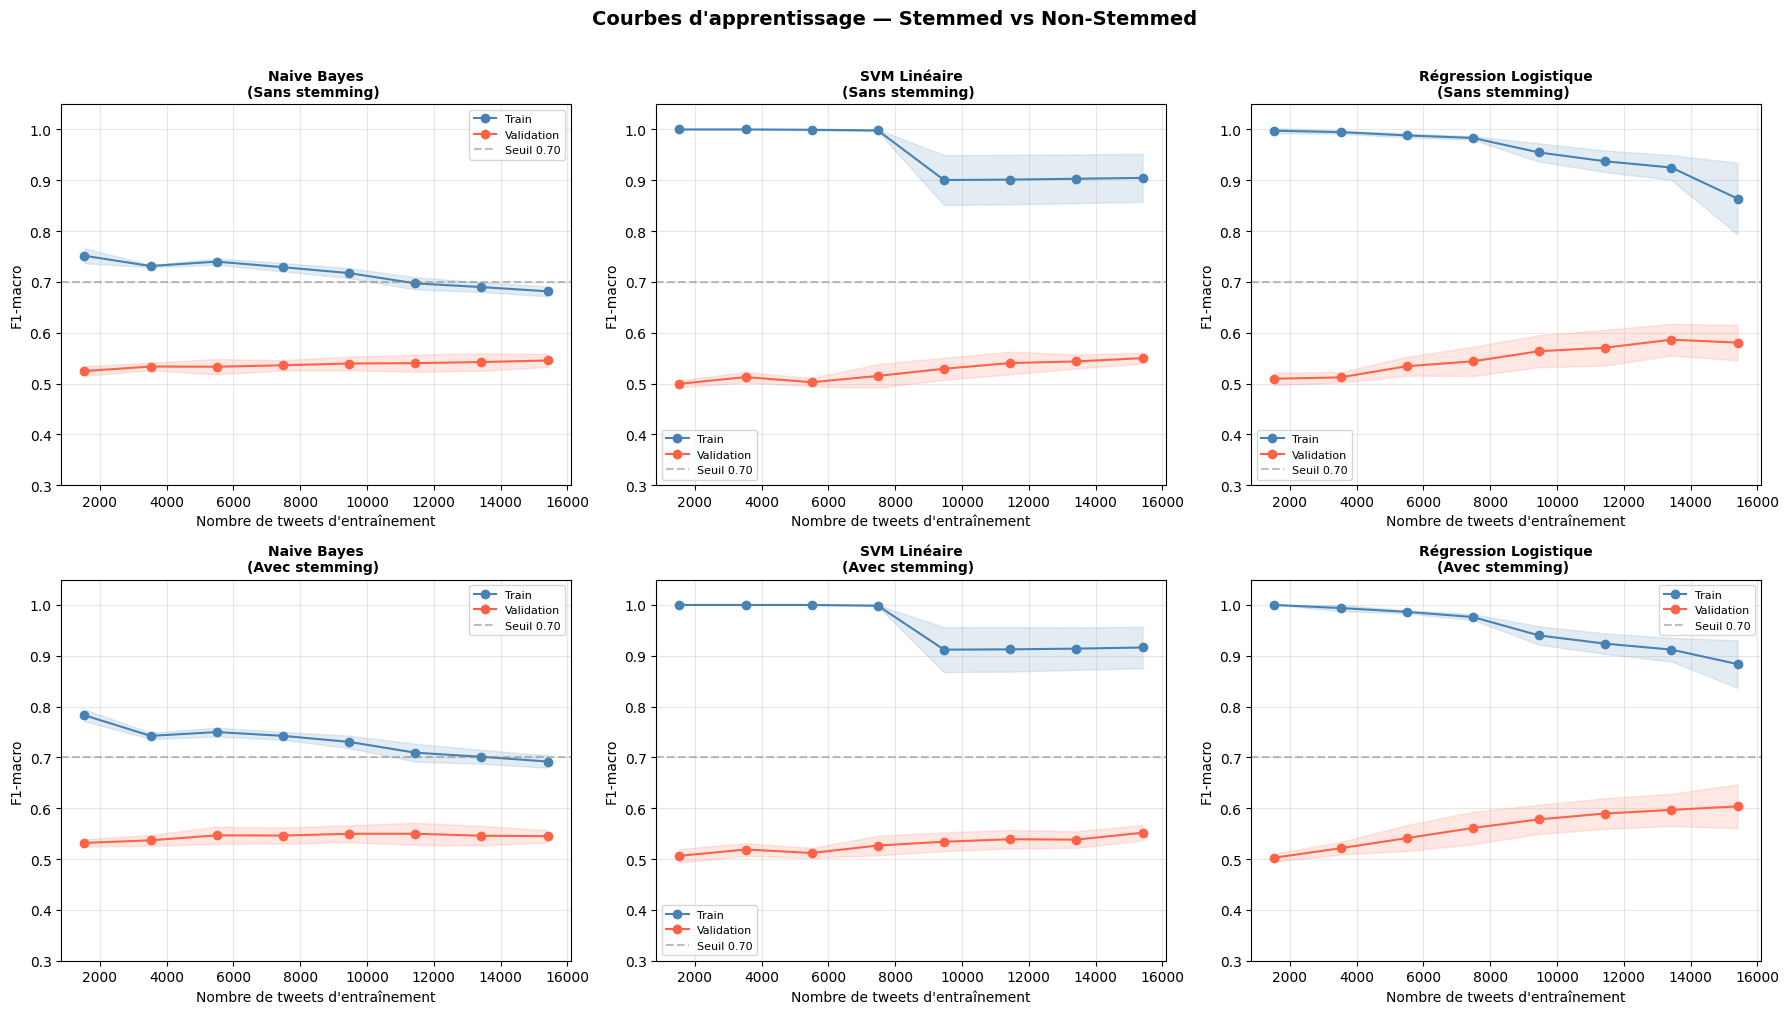

In [26]:
# ══════════════════════════════════════════════════════════════
#  COURBES D'APPRENTISSAGE — Diagnostic Overfit / Underfit
# ══════════════════════════════════════════════════════════════

from sklearn.model_selection import learning_curve
n_versions = len(VERSIONS)
n_modeles  = len(MODELES)
fig, axes = plt.subplots(n_versions, n_modeles, figsize=(6 * n_modeles, 5 * n_versions))
fig.suptitle("Courbes d'apprentissage — Stemmed vs Non-Stemmed",
             fontsize=14, fontweight='bold', y=1.01)

train_sizes = np.linspace(0.1, 1.0, 8)

for i, (version_nom, X) in enumerate(VERSIONS.items()):
    for j, (nom_clf, clf) in enumerate(MODELES.items()):

        pipeline = make_pipeline(clf)

        train_sizes_abs, train_scores, val_scores = learning_curve(
            pipeline, X, y,
            train_sizes=train_sizes,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='f1_macro',
            n_jobs=-1
        )

        train_mean = train_scores.mean(axis=1)
        train_std  = train_scores.std(axis=1)
        val_mean   = val_scores.mean(axis=1)
        val_std    = val_scores.std(axis=1)



        # ── Tracé ─────────────────────────────────────────────
        ax = axes[i][j]

        ax.plot(train_sizes_abs, train_mean, 'o-', color='steelblue', label='Train')
        ax.fill_between(train_sizes_abs,
                        train_mean - train_std,
                        train_mean + train_std,
                        alpha=0.15, color='steelblue')

        ax.plot(train_sizes_abs, val_mean, 'o-', color='tomato', label='Validation')
        ax.fill_between(train_sizes_abs,
                        val_mean - val_std,
                        val_mean + val_std,
                        alpha=0.15, color='tomato')

        ax.axhline(y=0.70, color='gray', linestyle='--', alpha=0.5, label='Seuil 0.70')
        ax.set_title(f'{nom_clf}\n({version_nom}) ', fontsize=10, fontweight='bold')
        ax.set_xlabel("Nombre de tweets d'entraînement")
        ax.set_ylabel('F1-macro')
        ax.set_ylim(0.3, 1.05)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
